# 🎯 AI-Powered Customer Churn Prediction & Retention Intelligence System

**Course:** Machine Learning (SE-CD-638) | **Instructor:** Dr. Aamir Arsalan | **Version:** v5.0 FINAL

| Phase | Description | Mapped WP |
|-------|-------------|-----------|
| **Phase 1** | Problem Selection, Dataset Collection & Preprocessing | WP2 |
| **Phase 2** | Supervised & Unsupervised Model Implementation | WP1, WP3 |
| **Phase 3** | Evaluation & Visualization | WP1, WP3 |
| **Phase 4** | Hyperparameter Tuning & Optimization | WP1, WP2, WP3 |

---
# Phase 1: Problem Selection, Dataset Collection & Preprocessing
*Mapped to WP2 — Range of Conflicting Requirements*

## 1.1 Library Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, time, pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, StackingClassifier, ExtraTreesClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, classification_report)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## 1.2 Data Loading & Exploration

In [ ]:
df = pd.read_csv('dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTarget Distribution:")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {(df['Churn']=='Yes').mean()*100:.2f}%")
df.describe()

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Target Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.54%


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 1.3 Data Cleaning

In [ ]:
data_path = 'dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv'

# Fix TotalCharges — stored as string in raw data
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Missing TotalCharges after conversion: {df['TotalCharges'].isnull().sum()} rows")

# Verify tenure of missing rows before filling
raw_check = pd.read_csv(data_path)
raw_check['TotalCharges'] = pd.to_numeric(raw_check['TotalCharges'], errors='coerce')
print("Tenure values of missing TotalCharges rows:",
      raw_check[raw_check['TotalCharges'].isnull()]['tenure'].values)
# All are tenure=0 (new customers, not yet billed) -> filling with 0 is correct, not arbitrary
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df.drop('customerID', axis=1, inplace=True)   # irrelevant identifier
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(f"Churn encoded: {df['Churn'].value_counts().to_dict()}")
print(f"Dataset shape after cleaning: {df.shape}")

Missing TotalCharges after conversion: 11 rows
Tenure values of missing TotalCharges rows: [0 0 0 0 0 0 0 0 0 0 0]
Churn encoded: {0: 5174, 1: 1869}
Dataset shape after cleaning: (7043, 20)


## 1.4 Outlier Treatment — Winsorization (IQR Method)
> **Important:** Outlier treatment is performed **before** feature engineering so that derived features
> (e.g. `AvgMonthlySpend`, `RiskScore`, `ChargesTenureIndex`) are computed from clean values.

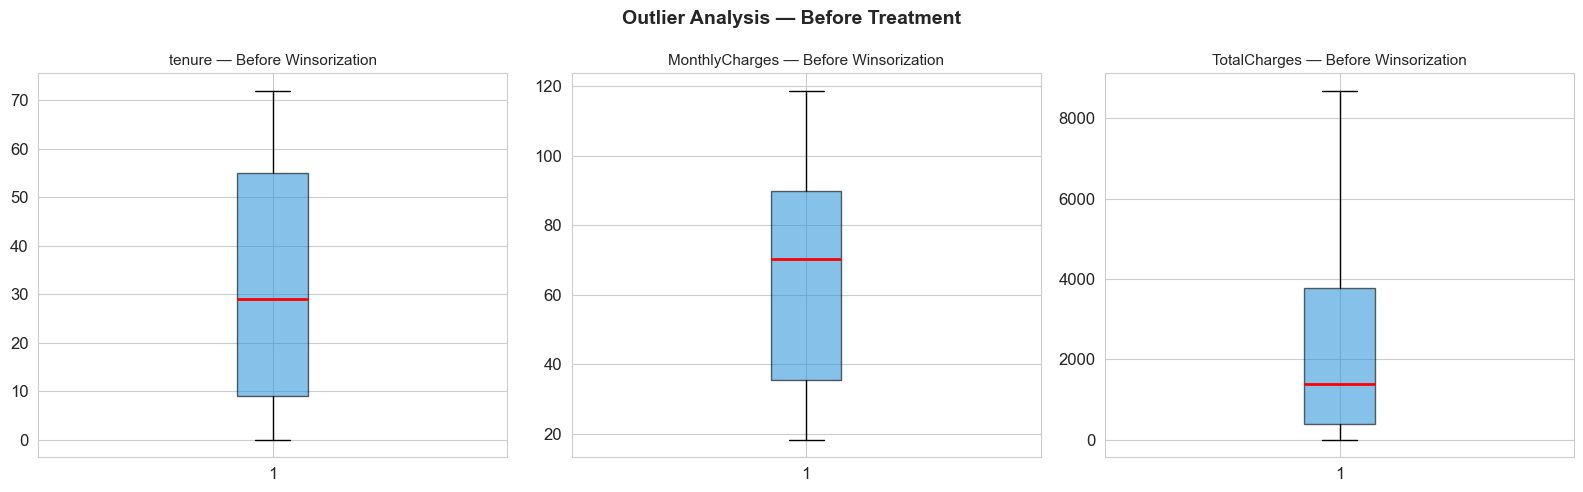

✅ Winsorization applied to MonthlyCharges & TotalCharges BEFORE feature engineering


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(['tenure', 'MonthlyCharges', 'TotalCharges']):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(f'{col} — Before Winsorization', fontsize=11)
plt.suptitle('Outlier Analysis — Before Treatment', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('05_outlier_before.png', dpi=150, bbox_inches='tight'); plt.show()

for col in ['MonthlyCharges', 'TotalCharges']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
print("✅ Winsorization applied to MonthlyCharges & TotalCharges BEFORE feature engineering")

## 1.5 Feature Engineering

In [ ]:
# --- Basic Features ---
services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity',
            'OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
df['TotalServices'] = df[services].apply(
    lambda r: sum(1 for v in r if v not in ['No','No internet service','No phone service']), axis=1)
df['AvgMonthlySpend'] = df.apply(
    lambda r: r['TotalCharges']/r['tenure'] if r['tenure'] > 0 else r['MonthlyCharges'], axis=1)
df['ContractTypeScore'] = df['Contract'].map({'Month-to-month':0,'One year':1,'Two year':2})

# --- Interaction Features ---
df['Fiber_NoSecurity']  = ((df['InternetService']=='Fiber optic') & (df['OnlineSecurity']=='No')).astype(int)
df['Fiber_NoTech']      = ((df['InternetService']=='Fiber optic') & (df['TechSupport']=='No')).astype(int)
df['MtM_LowTenure']     = ((df['Contract']=='Month-to-month') & (df['tenure']<=12)).astype(int)
df['MtM_HighCharges']   = ((df['Contract']=='Month-to-month') & (df['MonthlyCharges']>70)).astype(int)
df['Senior_NoSupport']  = ((df['SeniorCitizen']==1) & (df['TechSupport']=='No')).astype(int)
df['ElecCheck_MtM']     = ((df['PaymentMethod']=='Electronic check') & (df['Contract']=='Month-to-month')).astype(int)
df['NoFamily_MtM']      = ((df['Partner']=='No') & (df['Dependents']=='No') & (df['Contract']=='Month-to-month')).astype(int)

# --- Ratio Features ---
df['ChargesPerService']  = df['MonthlyCharges'] / (df['TotalServices'] + 1)
df['TenureChargeRatio']  = df['tenure'] / (df['MonthlyCharges'] + 1)
df['ChargesTenureIndex'] = df['MonthlyCharges'] * np.log1p(df['tenure'])

# --- Composite Risk & Loyalty Scores ---
def compute_risk_score(row):
    s = 0
    if row['Contract']      == 'Month-to-month':   s += 3
    if row['tenure']        <= 12:                  s += 2
    if row['InternetService']== 'Fiber optic':      s += 2
    if row['TechSupport']   == 'No':                s += 1
    if row['OnlineSecurity']== 'No':                s += 1
    if row['PaymentMethod'] == 'Electronic check':  s += 1
    if row['MonthlyCharges']> 80:                   s += 1
    if row['SeniorCitizen'] == 1:                   s += 1
    return s

df['RiskScore']   = df.apply(compute_risk_score, axis=1)
df['LoyaltyScore']= ((df['tenure']>24).astype(int)
                    + (df['Contract']=='Two year').astype(int)*2
                    + (df['TotalServices']>=4).astype(int)
                    + (df['Partner']=='Yes').astype(int)
                    + (df['Dependents']=='Yes').astype(int))
df['RiskLoyaltyRatio'] = df['RiskScore'] / (df['LoyaltyScore'] + 1)

# --- Polynomial & Derived Features ---
df['tenure_sq']             = df['tenure'] ** 2
df['tenure_monthly']        = df['tenure'] * df['MonthlyCharges']
df['log_total']             = np.log1p(df['TotalCharges'])
df['is_new']                = (df['tenure'] <= 6).astype(int)
df['is_veteran']            = (df['tenure'] >= 48).astype(int)
df['no_protection']         = ((df['OnlineSecurity']=='No') & (df['TechSupport']=='No') & (df['OnlineBackup']=='No')).astype(int)
df['full_protection']       = ((df['OnlineSecurity']=='Yes') & (df['TechSupport']=='Yes')).astype(int)
df['low_tenure_high_charge']= ((df['tenure']<=12) & (df['MonthlyCharges']>70)).astype(int)

print(f"✅ Feature engineering complete — {df.shape[1]-1} total features")
print(f"   (Outliers were winsorized BEFORE these features were computed)")
print(f"Dataset shape: {df.shape}")

✅ Feature engineering complete — 43 total features
   (Outliers were winsorized BEFORE these features were computed)
Dataset shape: (7043, 44)


## 1.6 EDA — Visualizations

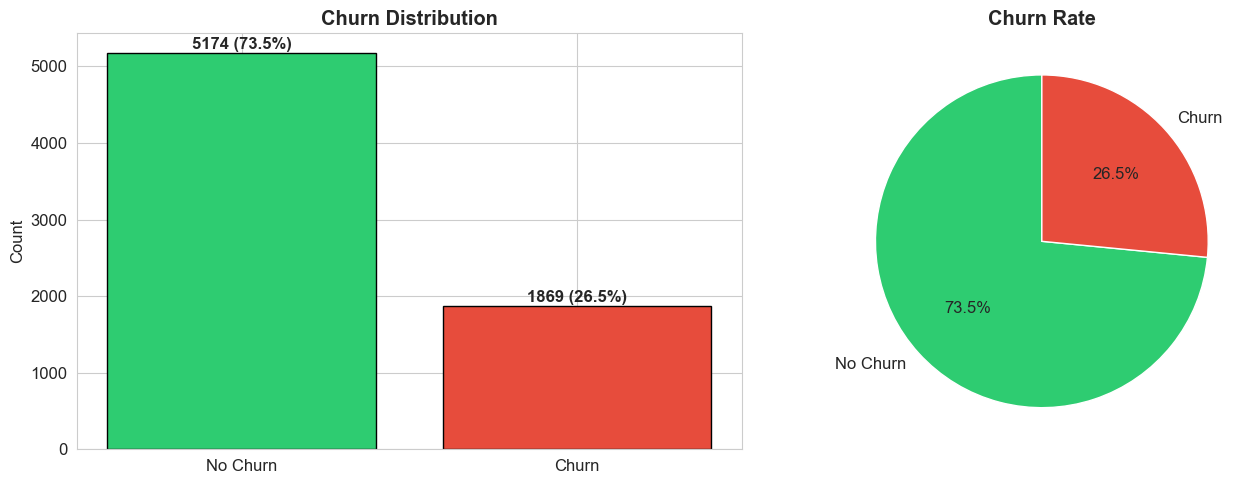

Churn Rate: 26.54%


In [ ]:
# Churn Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#e74c3c']
churn_counts = df['Churn'].value_counts()
axes[0].bar(['No Churn','Churn'], churn_counts.values, color=colors, edgecolor='black')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v+50, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Churn Distribution', fontweight='bold'); axes[0].set_ylabel('Count')
axes[1].pie(churn_counts.values, labels=['No Churn','Churn'],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Churn Rate', fontweight='bold')
plt.tight_layout(); plt.savefig('01_churn_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"Churn Rate: {(df['Churn']==1).mean()*100:.2f}%")

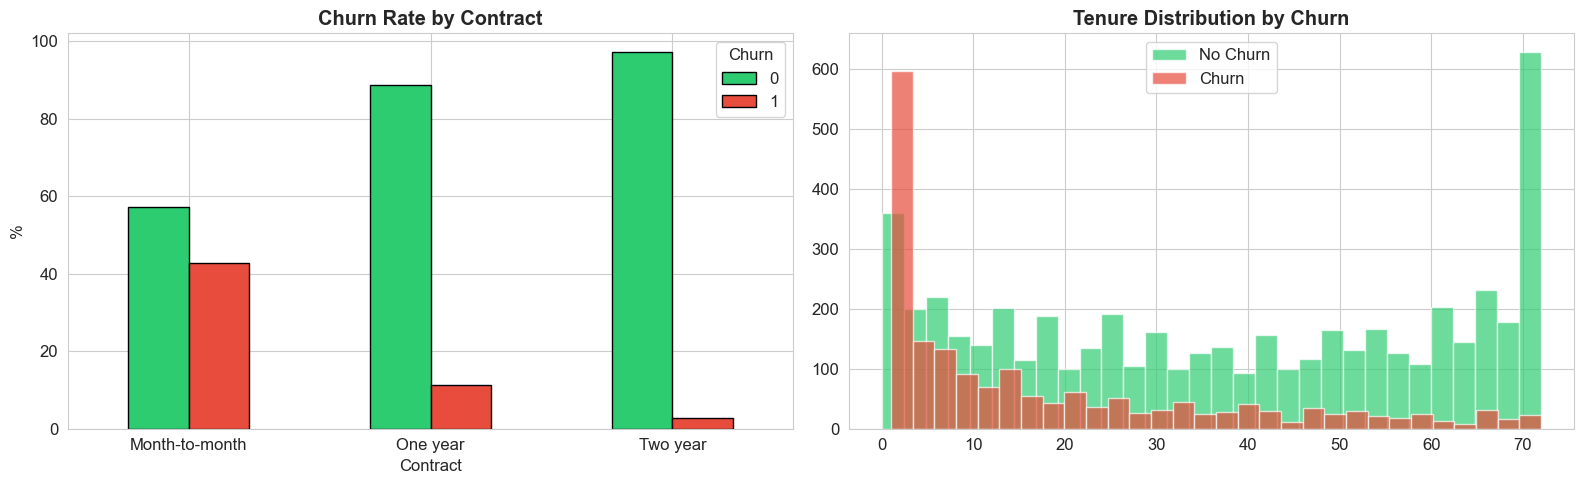

In [ ]:
# Contract & Tenure
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
ct.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='black')
axes[0].set_title('Churn Rate by Contract', fontweight='bold')
axes[0].set_ylabel('%'); axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for c, col, lbl in [(0,'#2ecc71','No Churn'),(1,'#e74c3c','Churn')]:
    axes[1].hist(df[df['Churn']==c]['tenure'], bins=30, alpha=0.7, color=col, label=lbl, edgecolor='white')
axes[1].set_title('Tenure Distribution by Churn', fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.savefig('02_contract_tenure.png', dpi=150, bbox_inches='tight'); plt.show()

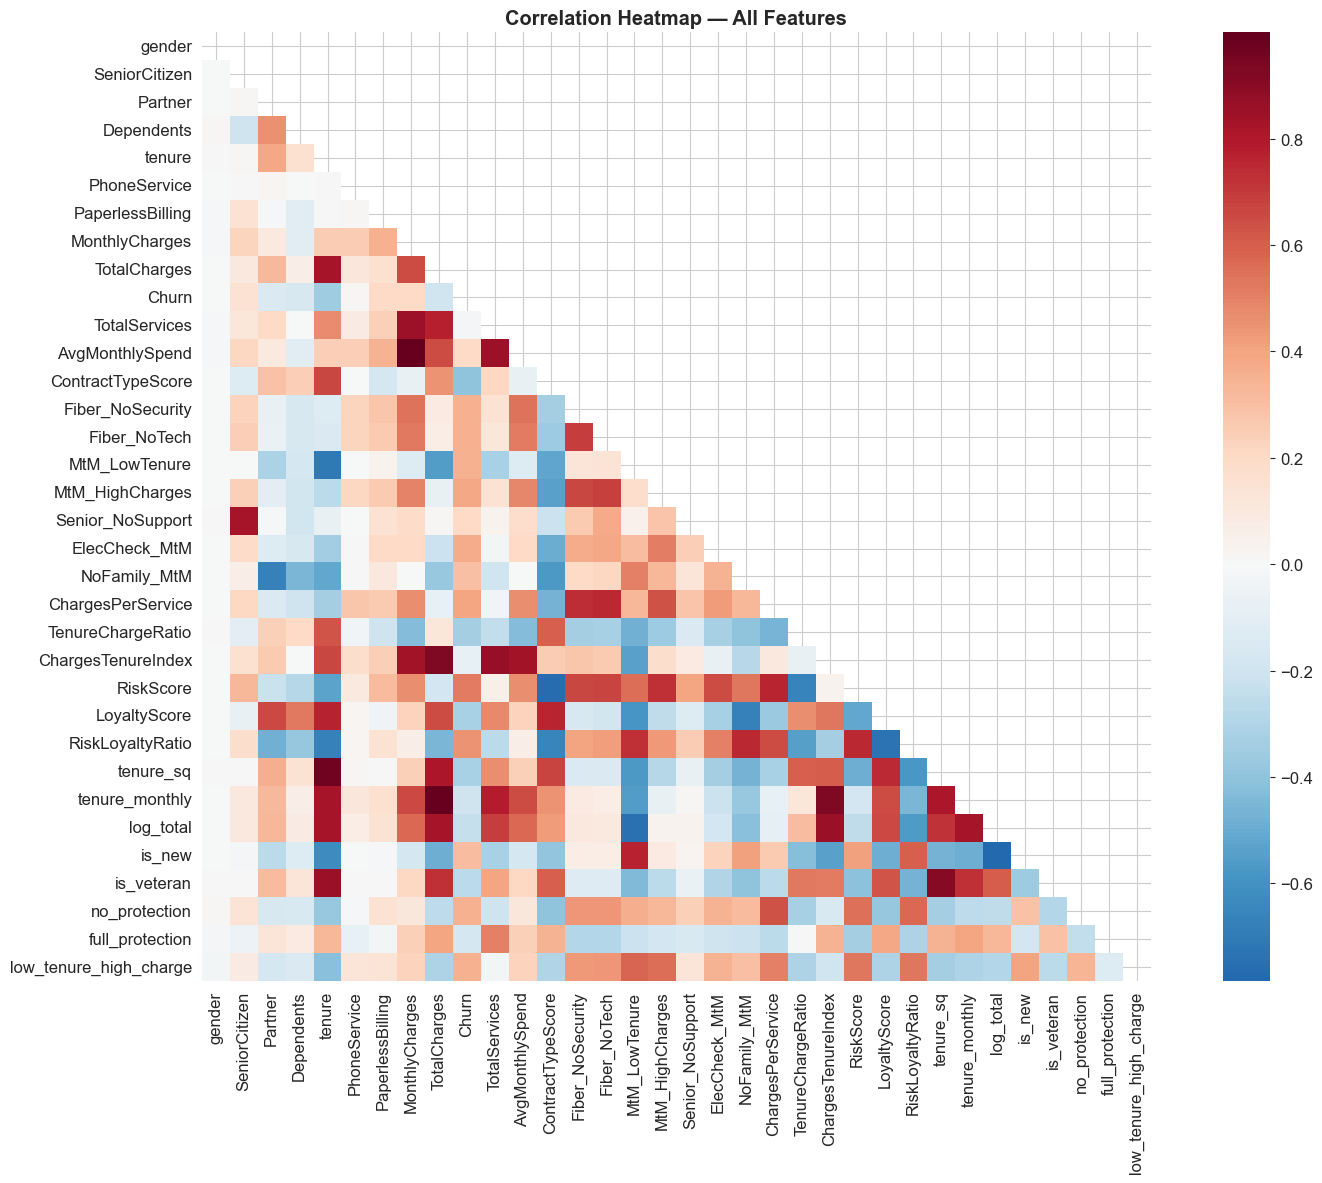

In [ ]:
# Correlation Heatmap
df_temp = df.copy()
for col in ['gender','Partner','Dependents','PhoneService','PaperlessBilling']:
    df_temp[col] = df_temp[col].map({'Yes':1,'No':0,'Male':1,'Female':0})
corr = df_temp.select_dtypes(include=[np.number]).corr()
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=False, cmap='RdBu_r', center=0, square=True, ax=ax)
ax.set_title('Correlation Heatmap — All Features', fontweight='bold')
plt.tight_layout(); plt.savefig('03_correlation.png', dpi=150, bbox_inches='tight'); plt.show()

## 1.7 Encoding & Train/Test Split

**Why TenureGroup is dropped:** It is a categorical binning of the continuous `tenure` feature, which is
already present. Keeping it would create redundant OHE columns.  
**Split:** Standard 80/20 stratified split.

In [ ]:
# Label Encoding — binary columns
# Using explicit map() instead of LabelEncoder loop to avoid
# shared-state issues and ensure consistent 0/1 assignment
binary_maps = {
    'gender'          : {'Female': 0, 'Male': 1},
    'Partner'         : {'No': 0, 'Yes': 1},
    'Dependents'      : {'No': 0, 'Yes': 1},
    'PhoneService'    : {'No': 0, 'Yes': 1},
    'PaperlessBilling': {'No': 0, 'Yes': 1},
}
for col, mapping in binary_maps.items():
    df[col] = df[col].map(mapping)
print("Binary encoding applied:", {c: sorted(df[c].unique().tolist()) for c in binary_maps})

# One-Hot Encoding — multi-class columns
multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']
df_encoded = pd.get_dummies(df, columns=multi_cols, drop_first=True)

X = df_encoded.drop(['Churn'], axis=1, errors='ignore')
y = df_encoded['Churn']
print(f"Final feature count : {X.shape[1]}")
print(f"Total samples       : {X.shape[0]}")
print(f"Class balance       : {y.value_counts().to_dict()}")

Binary encoding applied: {'gender': [0, 1], 'Partner': [0, 1], 'Dependents': [0, 1], 'PhoneService': [0, 1], 'PaperlessBilling': [0, 1]}
Final feature count : 54
Total samples       : 7043
Class balance       : {0: 5174, 1: 1869}


In [ ]:
# 80/20 Train/Test Split (standard practice — avoids inflated metrics from small test sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Further split train → train_sub + validation
# Validation set is ONLY used for threshold tuning — never touches the final test set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

# scaler : fitted on X_tr  — used for notebook evaluation metrics
scaler = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)
X_val_s  = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# scaler_full : fitted on full X_train — saved to pickle for the Streamlit app
scaler_full = StandardScaler()
X_train_s = scaler_full.fit_transform(X_train)

print(f"Train sub-set  (model training): {X_tr_s.shape}")
print(f"Validation set (threshold only): {X_val_s.shape}")
print(f"Test set       (final eval):     {X_test_s.shape}")
print(f"Full train     (pickle/app):     {X_train_s.shape}")
print("✅ Two separate scalers: scaler (X_tr) for eval | scaler_full (X_train) for pickle")

Train sub-set  (model training): (4788, 54)
Validation set (threshold only): (846, 54)
Test set       (final eval):     (1409, 54)
Full train     (pickle/app):     (5634, 54)
✅ Two separate scalers: scaler (X_tr) for eval | scaler_full (X_train) for pickle


## 1.8 SMOTE — Handling Class Imbalance

In [ ]:
# SMOTE applied ONLY to the training sub-split (never to val or test)
smote = SMOTE(random_state=42, k_neighbors=5)

# Store counts BEFORE resampling so we print them correctly
before_counts = dict(zip(*np.unique(y_tr, return_counts=True)))
X_res, y_res = smote.fit_resample(X_tr_s, y_tr)
after_counts  = dict(zip(*np.unique(y_res, return_counts=True)))

print(f"Class distribution BEFORE SMOTE : {before_counts}")
print(f"Class distribution AFTER  SMOTE : {after_counts}")
print(f"Original imbalance ratio        : {before_counts[0]/before_counts[1]:.2f}:1")
print("✅ SMOTE applied to training sub-split only (validation & test remain untouched)")

# Also resample full train for final pickle models
X_res_full, y_res_full = smote.fit_resample(X_train_s, y_train)
print(f"\nFull-train SMOTE shape: {X_res_full.shape}")

Class distribution BEFORE SMOTE : {np.int64(0): np.int64(3517), np.int64(1): np.int64(1271)}
Class distribution AFTER  SMOTE : {np.int64(0): np.int64(3517), np.int64(1): np.int64(3517)}
Original imbalance ratio        : 2.77:1
✅ SMOTE applied to training sub-split only (validation & test remain untouched)

Full-train SMOTE shape: (8278, 54)


---
# Phase 2: Supervised & Unsupervised Model Implementation
*Mapped to WP1 — Depth of Knowledge, WP3 — Depth of Analysis*

> **Fair Comparison:** ALL 10 models are trained on the same SMOTE-balanced data.  
> **Train Accuracy** is reported on the **original (non-SMOTE) train sub-set** — the honest metric.

## 2.1 Supervised Learning — All 10 Models (SMOTE-balanced, fair comparison)

In [ ]:
all_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', verbosity=0),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42, C=1.0),
    'k-NN':                KNeighborsClassifier(n_neighbors=5),
    'LightGBM':            LGBMClassifier(n_estimators=400, learning_rate=0.03, max_depth=8,
                                           num_leaves=60, subsample=0.85, colsample_bytree=0.85,
                                           min_child_samples=10, random_state=42, verbose=-1),
    'CatBoost':            CatBoostClassifier(iterations=400, learning_rate=0.03, depth=7,
                                               l2_leaf_reg=3, random_seed=42, verbose=0),
    'ExtraTrees':          ExtraTreesClassifier(n_estimators=300, max_depth=15, min_samples_leaf=2,
                                                 random_state=42, n_jobs=-1),
    'GradientBoosting':    GradientBoostingClassifier(n_estimators=300, learning_rate=0.03,
                                                       max_depth=6, subsample=0.85, random_state=42),
}

results = {}
trained = {}

for name, model in all_models.items():
    t0 = time.time()
    model.fit(X_res, y_res)          # ALL on SMOTE data — fair comparison
    elapsed = time.time() - t0

    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    tr_acc = accuracy_score(y_tr, model.predict(X_tr_s))   # on ORIGINAL, not SMOTE

    results[name] = {
        'Train Acc (Original)': tr_acc,
        'Test Accuracy' : accuracy_score(y_test, y_pred),
        'Precision'     : precision_score(y_test, y_pred),
        'Recall'        : recall_score(y_test, y_pred),
        'F1-Score'      : f1_score(y_test, y_pred),
        'ROC-AUC'       : roc_auc_score(y_test, y_prob),
        'Time (s)'      : round(elapsed, 2)
    }
    trained[name] = {'model': model, 'pred': y_pred, 'prob': y_prob}
    print(f"  {name:<22}  Train(Orig)={tr_acc:.4f}  Test={results[name]['Test Accuracy']:.4f}"
          f"  F1={results[name]['F1-Score']:.4f}  AUC={results[name]['ROC-AUC']:.4f}")

res_df = pd.DataFrame(results).T
print("\n" + "="*80)
print("ALL MODELS — FAIR COMPARISON  (all trained on SMOTE | train acc = original set)")
print("="*80)
print(res_df[['Train Acc (Original)','Test Accuracy','Precision','Recall','F1-Score','ROC-AUC']].round(4).to_string())

  Logistic Regression     Train(Orig)=0.7581  Test=0.7417  F1=0.6216  AUC=0.8442
  Decision Tree           Train(Orig)=0.8231  Test=0.7651  F1=0.5826  AUC=0.7978
  Random Forest           Train(Orig)=0.9336  Test=0.7729  F1=0.6107  AUC=0.8355
  XGBoost                 Train(Orig)=0.9893  Test=0.7757  F1=0.5549  AUC=0.8095
  SVM                     Train(Orig)=0.7962  Test=0.7537  F1=0.6199  AUC=0.8266
  k-NN                    Train(Orig)=0.8041  Test=0.6998  F1=0.5635  AUC=0.7688
  LightGBM                Train(Orig)=0.9495  Test=0.7779  F1=0.5765  AUC=0.8262
  CatBoost                Train(Orig)=0.8584  Test=0.7807  F1=0.5940  AUC=0.8402
  ExtraTrees              Train(Orig)=0.9317  Test=0.7622  F1=0.5859  AUC=0.8310
  GradientBoosting        Train(Orig)=0.8920  Test=0.7793  F1=0.5803  AUC=0.8360

ALL MODELS — FAIR COMPARISON  (all trained on SMOTE | train acc = original set)
                     Train Acc (Original)  Test Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regre

## 2.2 Ensemble Models — Stacking & Soft Voting

In [ ]:
# --- Stacking Ensemble ---
print("Building Stacking Ensemble (cv=5)...")
stacker = StackingClassifier(
    estimators=[
        ('lgb',  LGBMClassifier(n_estimators=400, learning_rate=0.03, max_depth=8,
                                 num_leaves=60, subsample=0.85, colsample_bytree=0.85,
                                 min_child_samples=10, random_state=42, verbose=-1)),
        ('catb', CatBoostClassifier(iterations=400, learning_rate=0.03, depth=7,
                                     random_seed=42, verbose=0)),
        ('xgb',  XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=7,
                                subsample=0.85, colsample_bytree=0.85,
                                random_state=42, eval_metric='logloss', verbosity=0)),
        ('rf',   RandomForestClassifier(n_estimators=300, max_depth=12,
                                         min_samples_leaf=2, random_state=42, n_jobs=-1)),
        ('gb',   GradientBoostingClassifier(n_estimators=300, learning_rate=0.03,
                                             max_depth=6, subsample=0.85, random_state=42)),
    ],
    final_estimator=LogisticRegression(C=2.0, max_iter=1000, random_state=42),
    cv=5, stack_method='predict_proba', passthrough=False, n_jobs=-1)

stacker.fit(X_res, y_res)
stack_tr_acc  = accuracy_score(y_tr, stacker.predict(X_tr_s))
stack_te_pred = stacker.predict(X_test_s)
stack_te_prob = stacker.predict_proba(X_test_s)[:, 1]
stack_te_acc  = accuracy_score(y_test, stack_te_pred)
stack_te_f1   = f1_score(y_test, stack_te_pred)
stack_te_auc  = roc_auc_score(y_test, stack_te_prob)
print(f"Stacking  →  Train(Orig)={stack_tr_acc:.4f}  Test={stack_te_acc:.4f}"
      f"  F1={stack_te_f1:.4f}  AUC={stack_te_auc:.4f}")

# --- Soft Voting Ensemble ---
voter = VotingClassifier(
    estimators=[
        ('lgb',  LGBMClassifier(n_estimators=300, learning_rate=0.03, max_depth=8,
                                 random_state=42, verbose=-1)),
        ('catb', CatBoostClassifier(iterations=300, learning_rate=0.03, depth=7,
                                     random_seed=42, verbose=0)),
        ('xgb',  XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=7,
                                random_state=42, verbosity=0)),
    ], voting='soft', weights=[2, 2, 1])

voter.fit(X_res, y_res)
voter_tr_acc = accuracy_score(y_tr, voter.predict(X_tr_s))
voter_pred   = voter.predict(X_test_s)
voter_prob   = voter.predict_proba(X_test_s)[:, 1]
print(f"Voting    →  Train(Orig)={voter_tr_acc:.4f}  Test={accuracy_score(y_test,voter_pred):.4f}"
      f"  F1={f1_score(y_test,voter_pred):.4f}  AUC={roc_auc_score(y_test,voter_prob):.4f}")

Building Stacking Ensemble (cv=5)...
Stacking  →  Train(Orig)=0.9016  Test=0.7722  F1=0.5890  AUC=0.8381
Voting    →  Train(Orig)=0.8655  Test=0.7850  F1=0.6008  AUC=0.8374


## 2.3 Unsupervised Learning — K-Means, Agglomerative, DBSCAN

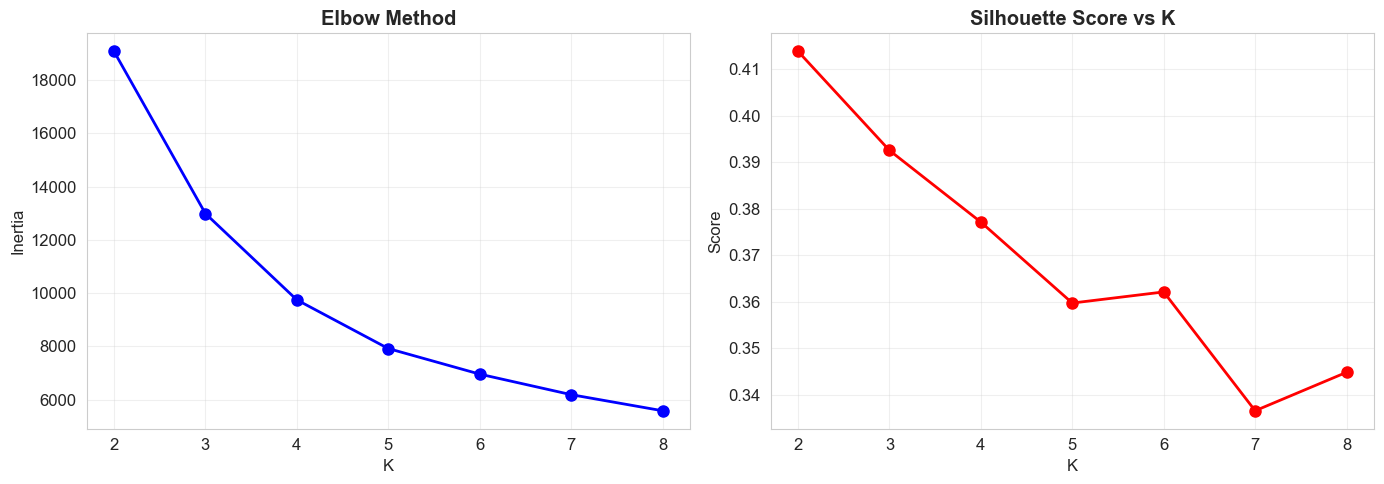

Optimal K (by silhouette): 2


In [ ]:
# Clustering on original numeric features — NOT OHE columns (standard practice)
cluster_features = ['tenure','MonthlyCharges','TotalCharges','TotalServices','ContractTypeScore']
X_clust   = df[cluster_features].copy()
X_clust_s = StandardScaler().fit_transform(X_clust)

# K selection — Elbow + Silhouette
inertias, sil_scores = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_s)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_clust_s, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(2,9), inertias,   'bo-', lw=2, ms=8)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia'); axes[0].grid(alpha=0.3)
axes[1].plot(range(2,9), sil_scores, 'ro-', lw=2, ms=8)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Score'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('11_kmeans_elbow.png', dpi=150, bbox_inches='tight'); plt.show()
optimal_k = range(2,9)[sil_scores.index(max(sil_scores))]
print(f"Optimal K (by silhouette): {optimal_k}")

K-Means (k=3)        →  Silhouette=0.3925  Davies-Bouldin=0.9865

Cluster Profiles:
         tenure  MonthlyCharges  TotalCharges  TotalServices  ContractTypeScore  Churn
Cluster                                                                               
0        15.853          73.261      1185.709          4.098              0.100  0.453
1        59.230          89.772      5317.242          6.673              1.289  0.133
2        29.692          24.061       738.368          1.485              0.986  0.108


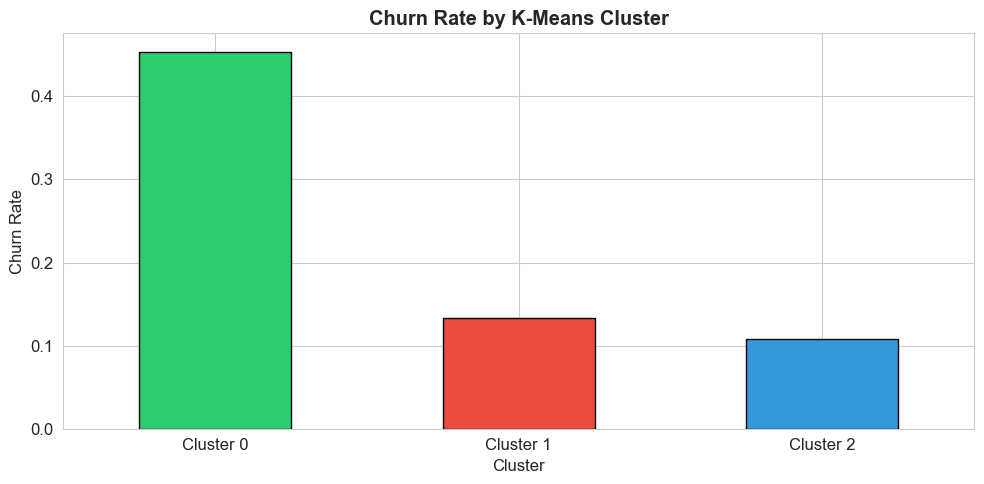


Agglomerative (k=3)  →  Silhouette=0.3659  Davies-Bouldin=1.0439


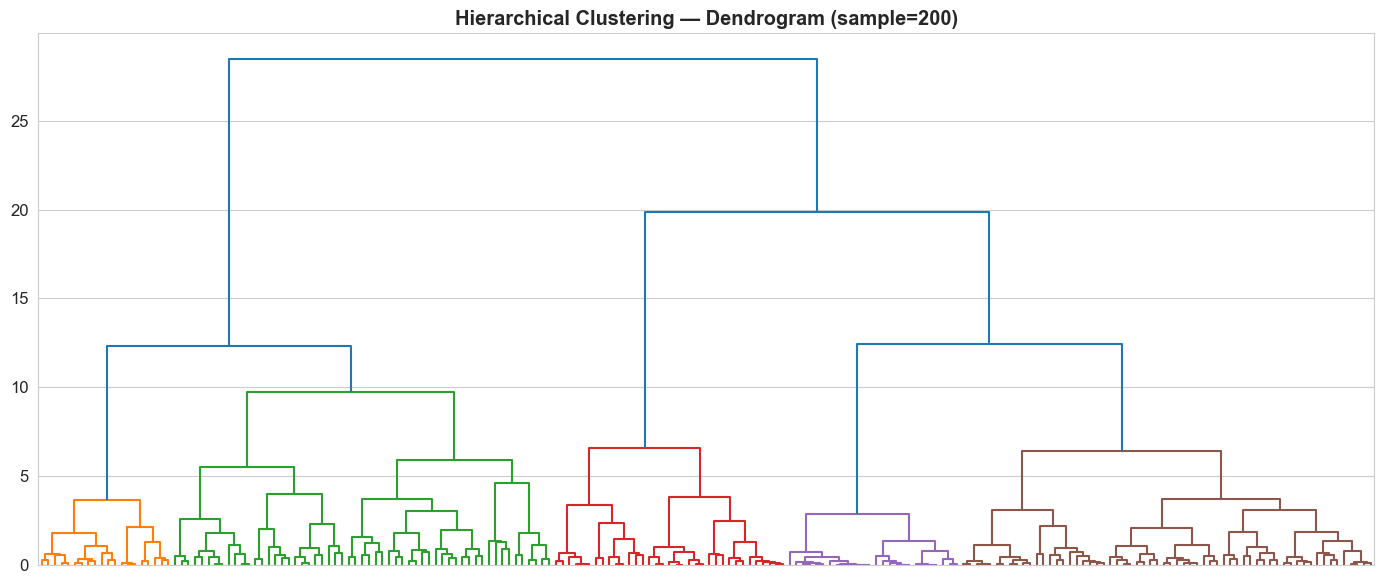


DBSCAN               →  Clusters=3  Noise points=7 (0.1%)
  Silhouette (non-noise) = 0.2158
  Davies-Bouldin         = 2.4539


In [ ]:
# --- K-Means (k=3 for business interpretability) ---
km3     = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X_clust_s)
km_sil  = silhouette_score(X_clust_s, km3.labels_)
km_dbi  = davies_bouldin_score(X_clust_s, km3.labels_)
print(f"K-Means (k=3)        →  Silhouette={km_sil:.4f}  Davies-Bouldin={km_dbi:.4f}")

profile           = df[cluster_features + ['Churn']].copy()
profile['Cluster']= km3.labels_
print("\nCluster Profiles:")
print(profile.groupby('Cluster').mean().round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
profile.groupby('Cluster')['Churn'].mean().plot(
    kind='bar', ax=ax, color=['#2ecc71','#e74c3c','#3498db'], edgecolor='black')
ax.set_title('Churn Rate by K-Means Cluster', fontweight='bold')
ax.set_ylabel('Churn Rate')
ax.set_xticklabels([f'Cluster {i}' for i in range(3)], rotation=0)
plt.tight_layout(); plt.savefig('12_cluster_churn.png', dpi=150, bbox_inches='tight'); plt.show()

# --- Agglomerative Clustering (Silhouette + DBI required by PDF) ---
agg     = AgglomerativeClustering(n_clusters=3).fit(X_clust_s)
agg_sil = silhouette_score(X_clust_s, agg.labels_)
agg_dbi = davies_bouldin_score(X_clust_s, agg.labels_)
print(f"\nAgglomerative (k=3)  →  Silhouette={agg_sil:.4f}  Davies-Bouldin={agg_dbi:.4f}")

fig, ax = plt.subplots(figsize=(14, 6))
Z = linkage(X_clust_s[:200], method='ward')
dendrogram(Z, ax=ax, no_labels=True, color_threshold=10)
ax.set_title('Hierarchical Clustering — Dendrogram (sample=200)', fontweight='bold')
plt.tight_layout(); plt.savefig('13_dendrogram.png', dpi=150, bbox_inches='tight'); plt.show()

# --- DBSCAN ---
db      = DBSCAN(eps=0.8, min_samples=20).fit(X_clust_s)
n_clust = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
noise   = (db.labels_ == -1).sum()
print(f"\nDBSCAN               →  Clusters={n_clust}  Noise points={noise} ({noise/len(db.labels_)*100:.1f}%)")
if n_clust > 1:
    mask = db.labels_ != -1
    print(f"  Silhouette (non-noise) = {silhouette_score(X_clust_s[mask], db.labels_[mask]):.4f}")
    print(f"  Davies-Bouldin         = {davies_bouldin_score(X_clust_s[mask], db.labels_[mask]):.4f}")

---
# Phase 3: Evaluation & Visualization
*Mapped to WP1, WP3*

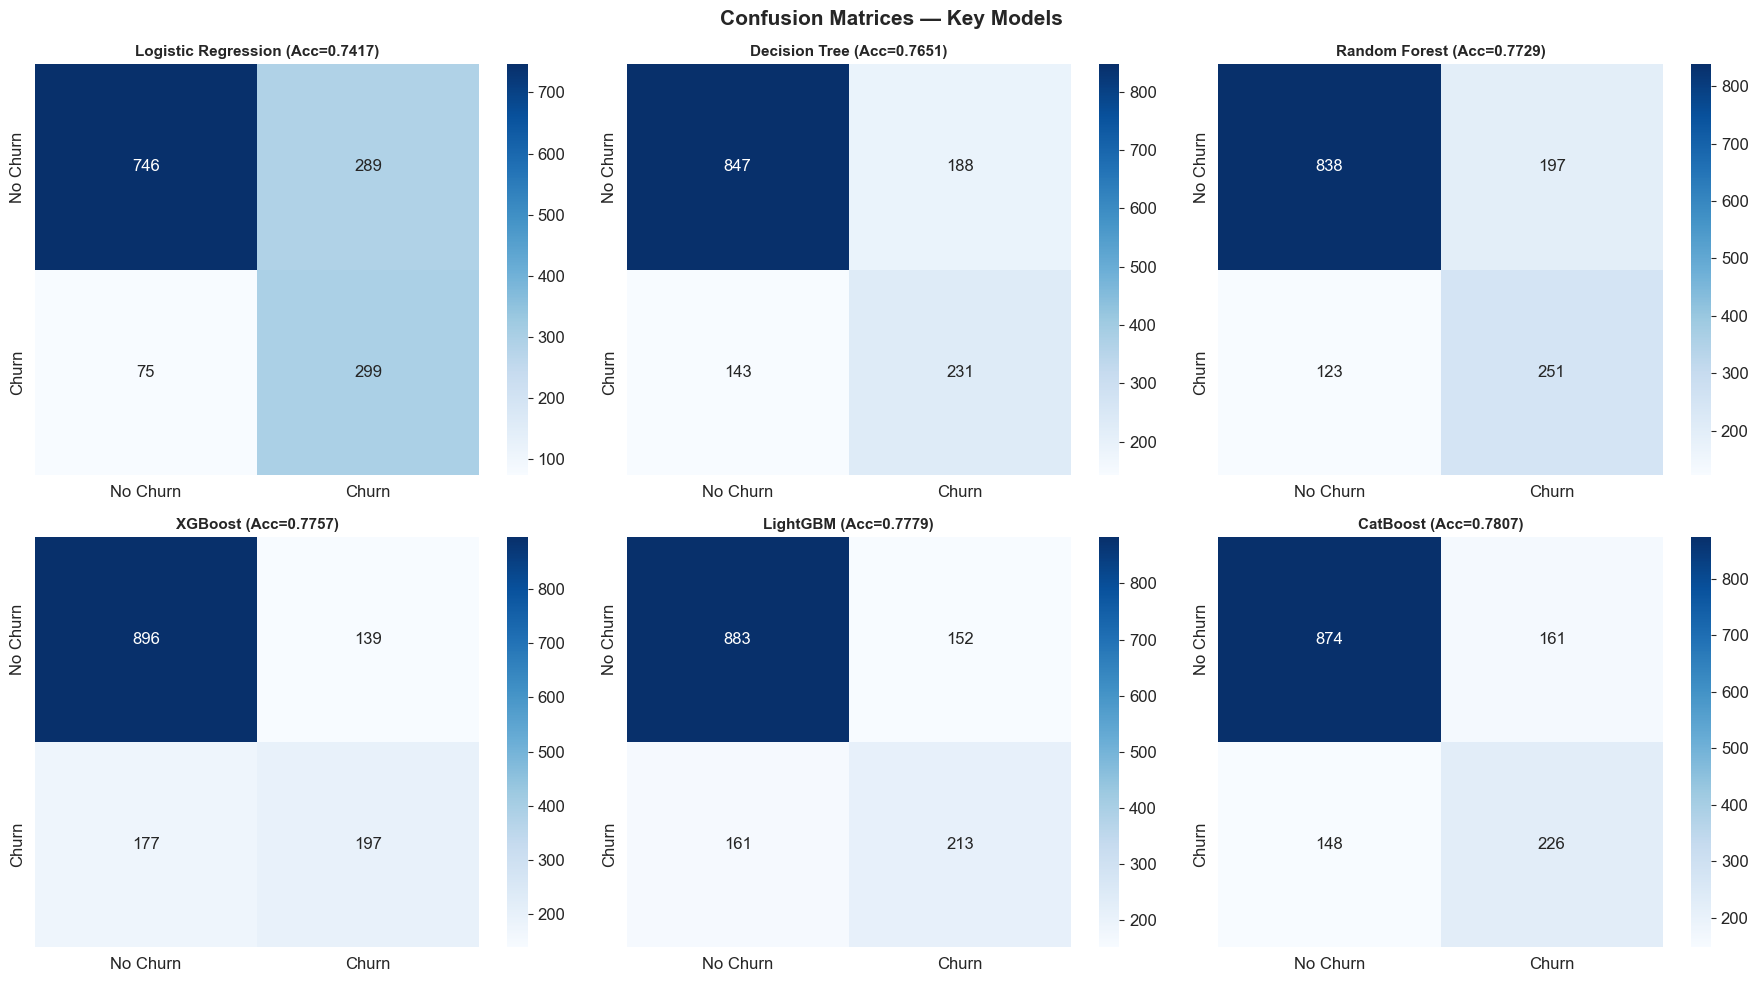

In [ ]:
# Confusion Matrices — 6 key models
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
key_models = ['Logistic Regression','Decision Tree','Random Forest','XGBoost','LightGBM','CatBoost']
for idx, name in enumerate(key_models):
    ax  = axes[idx // 3][idx % 3]
    cm  = confusion_matrix(y_test, trained[name]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(f'{name} (Acc={results[name]["Test Accuracy"]:.4f})',
                 fontweight='bold', fontsize=11)
plt.suptitle('Confusion Matrices — Key Models', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.savefig('08_confusion_matrices.png', dpi=150, bbox_inches='tight'); plt.show()

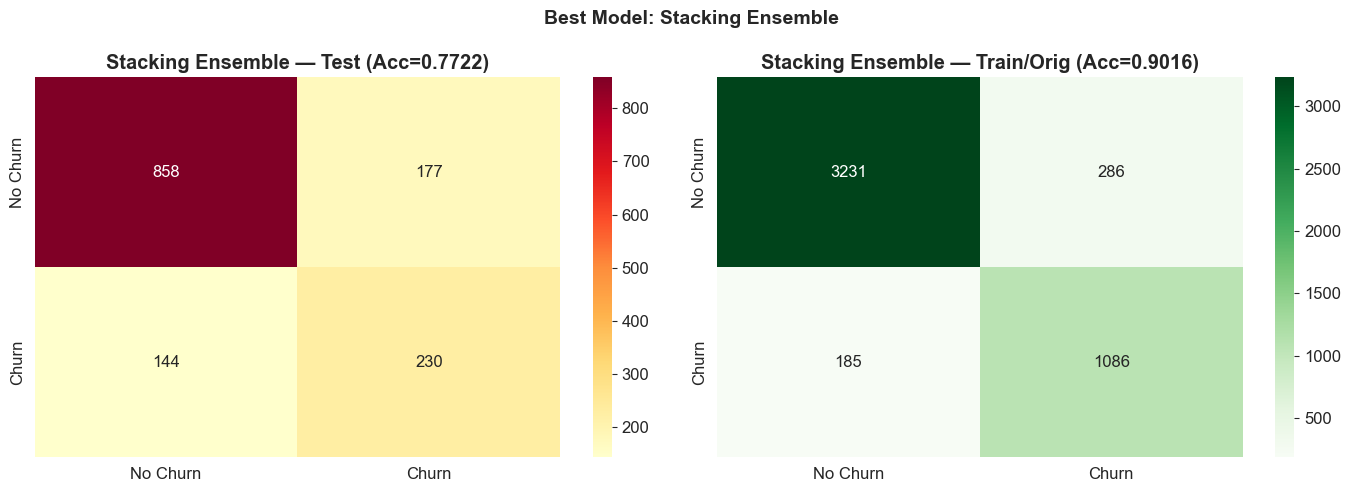

In [ ]:
# Confusion Matrix — Best Ensemble
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_te = confusion_matrix(y_test, stack_te_pred)
sns.heatmap(cm_te, annot=True, fmt='d', cmap='YlOrRd', ax=axes[0],
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
axes[0].set_title(f'Stacking Ensemble — Test (Acc={stack_te_acc:.4f})', fontweight='bold')

cm_tr = confusion_matrix(y_tr, stacker.predict(X_tr_s))
sns.heatmap(cm_tr, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
axes[1].set_title(f'Stacking Ensemble — Train/Orig (Acc={stack_tr_acc:.4f})', fontweight='bold')
plt.suptitle('Best Model: Stacking Ensemble', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('08b_best_model_cm.png', dpi=150, bbox_inches='tight'); plt.show()

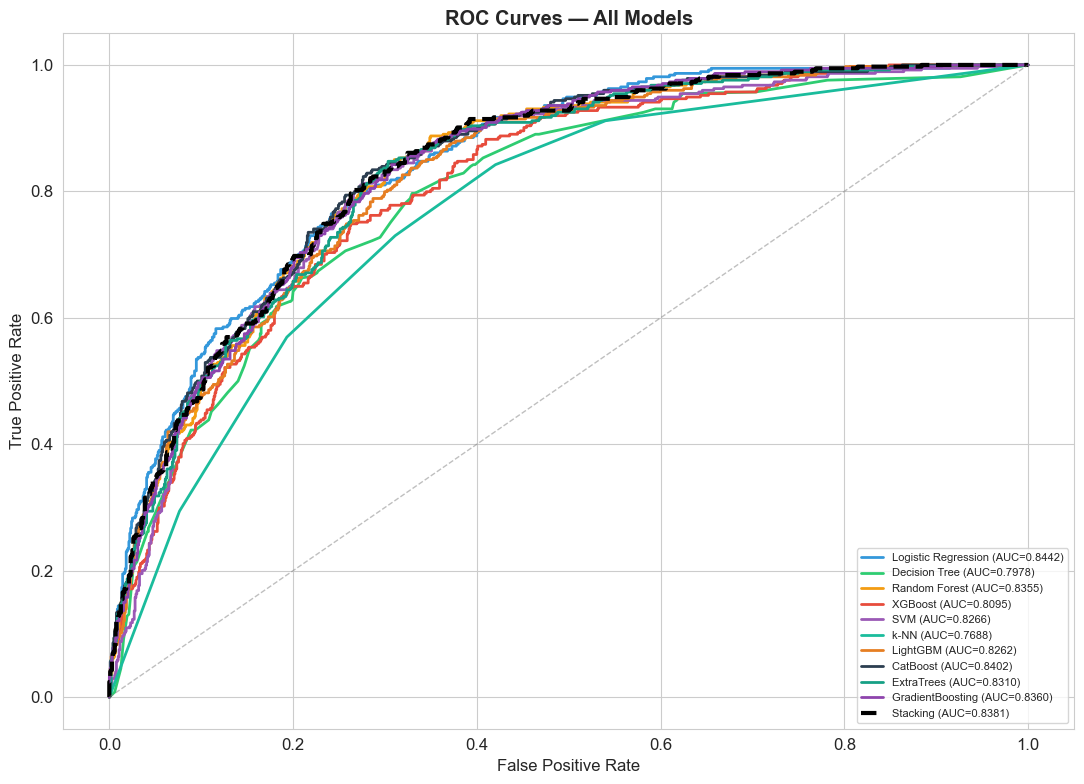

In [21]:
# ROC Curves — All Models
fig, ax = plt.subplots(figsize=(11, 8))
colors_roc = ['#3498db','#2ecc71','#f39c12','#e74c3c','#9b59b6',
               '#1abc9c','#e67e22','#2c3e50','#16a085','#8e44ad']
for idx, (name, data) in enumerate(trained.items()):
    fpr, tpr, _ = roc_curve(y_test, data['prob'])
    ax.plot(fpr, tpr, color=colors_roc[idx % len(colors_roc)], lw=2,
            label=f'{name} (AUC={results[name]["ROC-AUC"]:.4f})')
fpr_s, tpr_s, _ = roc_curve(y_test, stack_te_prob)
ax.plot(fpr_s, tpr_s, 'k--', lw=3, label=f'Stacking (AUC={stack_te_auc:.4f})')
ax.plot([0,1],[0,1], 'gray', lw=1, linestyle='--', alpha=0.5)
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.savefig('09_roc_curves.png', dpi=150, bbox_inches='tight'); plt.show()

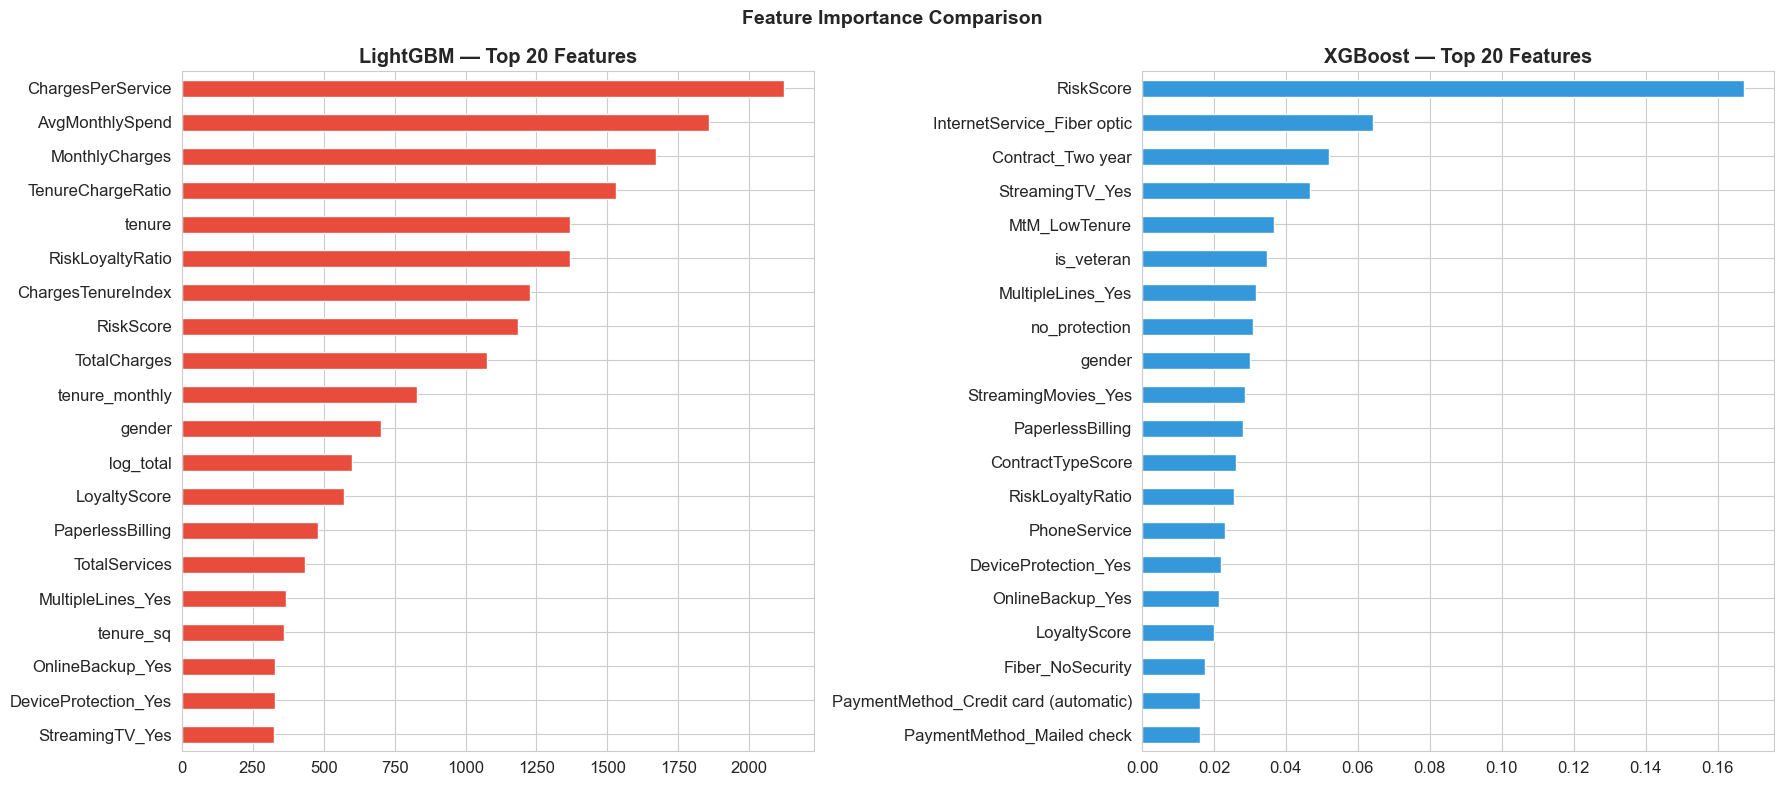

In [ ]:
# Feature Importance — LightGBM & XGBoost (Top 20)
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for idx, name in enumerate(['LightGBM', 'XGBoost']):
    fi = pd.Series(trained[name]['model'].feature_importances_,
                   index=X.columns).sort_values().tail(20)
    fi.plot(kind='barh', ax=axes[idx], color='#e74c3c' if idx==0 else '#3498db')
    axes[idx].set_title(f'{name} — Top 20 Features', fontweight='bold')
plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('10_feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()

## 3.4 Classification Report — Best Model (LightGBM)

In [ ]:
# Classification Report — per-class Precision, Recall, F1
# Required by CEP PDF: 'Accuracy, Precision, Recall, F1-score' per model
print("Classification Report — LightGBM (Best Performing Model)")
print("="*60)
print(classification_report(
    y_test,
    trained['LightGBM']['pred'],
    target_names=['No Churn', 'Churn']
))

print("\nClassification Report — Stacking Ensemble (Best Ensemble)")
print("="*60)
print(classification_report(
    y_test,
    stack_te_pred,
    target_names=['No Churn', 'Churn']
))

Classification Report — LightGBM (Best Performing Model)
              precision    recall  f1-score   support

    No Churn       0.85      0.85      0.85      1035
       Churn       0.58      0.57      0.58       374

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409


Classification Report — Stacking Ensemble (Best Ensemble)
              precision    recall  f1-score   support

    No Churn       0.86      0.83      0.84      1035
       Churn       0.57      0.61      0.59       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.72      1409
weighted avg       0.78      0.77      0.78      1409



## 4.0 Standalone k-Fold Cross-Validation
*Required by CEP PDF — k-Fold CV as an explicit generalization technique, separate from GridSearch/RandomSearch*

In [ ]:
# Standalone 5-Fold Stratified Cross-Validation — LightGBM (Best Model)
# CEP PDF Phase 4 requires k-Fold CV as an explicit technique under 'Improve model generalization'
print("5-Fold Stratified Cross-Validation — LightGBM")
print("="*55)

lgbm_cv = LGBMClassifier(n_estimators=400, learning_rate=0.03, max_depth=8,
                          num_leaves=60, subsample=0.85, colsample_bytree=0.85,
                          min_child_samples=10, random_state=42, verbose=-1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(lgbm_cv, X_res, y_res, cv=skf, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(lgbm_cv, X_res, y_res, cv=skf, scoring='f1',       n_jobs=-1)
cv_auc = cross_val_score(lgbm_cv, X_res, y_res, cv=skf, scoring='roc_auc',  n_jobs=-1)

print(f"Accuracy  per fold   : {cv_acc.round(4)}")
print(f"Accuracy  mean±std   : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print()
print(f"F1-Score  per fold   : {cv_f1.round(4)}")
print(f"F1-Score  mean±std   : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print()
print(f"ROC-AUC   per fold   : {cv_auc.round(4)}")
print(f"ROC-AUC   mean±std   : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print()
print("Low std across folds indicates model generalizes well (not overfit to one split)")

5-Fold Stratified Cross-Validation — LightGBM
Accuracy  per fold   : [0.8493 0.8763 0.8571 0.8472 0.8585]
Accuracy  mean±std   : 0.8577 ± 0.0103

F1-Score  per fold   : [0.852  0.8762 0.8561 0.8474 0.8588]
F1-Score  mean±std   : 0.8581 ± 0.0099

ROC-AUC   per fold   : [0.9335 0.948  0.9351 0.9338 0.9409]
ROC-AUC   mean±std   : 0.9383 ± 0.0056

Low std across folds indicates model generalizes well (not overfit to one split)


---
# Phase 4: Hyperparameter Tuning & Optimization
*Mapped to WP1, WP2, WP3*

## 4.1 GridSearchCV — Random Forest (5-Fold CV)

In [ ]:
print("GridSearchCV — Random Forest (cv=5)")
print("="*60)

rf_param_grid = {
    'n_estimators'    : [200, 400, 500],
    'max_depth'       : [12, 15, 18],
    'min_samples_leaf': [1, 2, 3],
    'min_samples_split': [2, 5]
}
total_combos = 3 * 3 * 3 * 2
print(f"Grid: {total_combos} combinations × 5-fold = {total_combos*5} fits")

t0 = time.time()
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
rf_grid.fit(X_res, y_res)
elapsed = time.time() - t0

rf_tuned = rf_grid.best_estimator_
rf_tr_acc = accuracy_score(y_tr, rf_tuned.predict(X_tr_s))
rf_te_acc = accuracy_score(y_test, rf_tuned.predict(X_test_s))
rf_te_f1  = f1_score(y_test, rf_tuned.predict(X_test_s))
rf_te_auc = roc_auc_score(y_test, rf_tuned.predict_proba(X_test_s)[:,1])

print(f"\n✅ Best Parameters : {rf_grid.best_params_}")
print(f"✅ Best CV Score    : {rf_grid.best_score_:.4f}")
print(f"✅ Train Acc (Orig) : {rf_tr_acc:.4f}")
print(f"✅ Test  Accuracy   : {rf_te_acc:.4f}")
print(f"✅ Test  F1-Score   : {rf_te_f1:.4f}")
print(f"✅ Test  ROC-AUC    : {rf_te_auc:.4f}")
print(f"⏱  Time             : {elapsed:.1f}s")
print(f"\n📊 RF Before: {results['Random Forest']['Test Accuracy']:.4f}"
      f"  →  After GridSearch: {rf_te_acc:.4f}"
      f"  (Δ {rf_te_acc - results['Random Forest']['Test Accuracy']:+.4f})")

GridSearchCV — Random Forest (cv=5)
Grid: 54 combinations × 5-fold = 270 fits

✅ Best Parameters : {'max_depth': 18, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
✅ Best CV Score    : 0.8526
✅ Train Acc (Orig) : 0.9971
✅ Test  Accuracy   : 0.7686
✅ Test  F1-Score   : 0.5799
✅ Test  ROC-AUC    : 0.8278
⏱  Time             : 391.0s

📊 RF Before: 0.7729  →  After GridSearch: 0.7686  (Δ -0.0043)


## 4.2 RandomizedSearchCV — LightGBM (5-Fold CV)

In [ ]:
print("RandomizedSearchCV — LightGBM (cv=5, n_iter=30)")
print("="*60)

lgbm_param_dist = {
    'n_estimators'    : [300, 500, 700, 800, 1000],
    'learning_rate'   : [0.01, 0.02, 0.03, 0.05],
    'max_depth'       : [6, 8, 10, 12],
    'num_leaves'      : [31, 50, 63, 80, 100],
    'min_child_samples': [5, 10, 20, 30],
    'subsample'       : [0.7, 0.8, 0.85, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.85, 0.9],
    'reg_alpha'       : [0, 0.01, 0.1, 0.5],
    'reg_lambda'      : [0, 0.01, 0.1, 0.5]
}

t0 = time.time()
lgb_rand = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    lgbm_param_dist, n_iter=30, cv=5, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=0)
lgb_rand.fit(X_res, y_res)
elapsed = time.time() - t0

lgb_tuned   = lgb_rand.best_estimator_
lgb_tr_acc  = accuracy_score(y_tr, lgb_tuned.predict(X_tr_s))
lgb_te_acc  = accuracy_score(y_test, lgb_tuned.predict(X_test_s))
lgb_te_f1   = f1_score(y_test, lgb_tuned.predict(X_test_s))
lgb_te_auc  = roc_auc_score(y_test, lgb_tuned.predict_proba(X_test_s)[:,1])

print("✅ Best Parameters:")
for k, v in lgb_rand.best_params_.items():
    print(f"   {k}: {v}")
print(f"\n✅ Best CV Score    : {lgb_rand.best_score_:.4f}")
print(f"✅ Train Acc (Orig) : {lgb_tr_acc:.4f}")
print(f"✅ Test  Accuracy   : {lgb_te_acc:.4f}")
print(f"✅ Test  F1-Score   : {lgb_te_f1:.4f}")
print(f"✅ Test  ROC-AUC    : {lgb_te_auc:.4f}")
print(f"⏱  Time             : {elapsed:.1f}s")
print(f"\n📊 LGB Before: {results['LightGBM']['Test Accuracy']:.4f}"
      f"  →  After RandomSearch: {lgb_te_acc:.4f}"
      f"  (Δ {lgb_te_acc - results['LightGBM']['Test Accuracy']:+.4f})")

RandomizedSearchCV — LightGBM (cv=5, n_iter=30)
✅ Best Parameters:
   subsample: 0.8
   reg_lambda: 0.01
   reg_alpha: 0.1
   num_leaves: 80
   n_estimators: 1000
   min_child_samples: 10
   max_depth: 12
   learning_rate: 0.02
   colsample_bytree: 0.85

✅ Best CV Score    : 0.8452
✅ Train Acc (Orig) : 0.9956
✅ Test  Accuracy   : 0.7850
✅ Test  F1-Score   : 0.5690
✅ Test  ROC-AUC    : 0.8227
⏱  Time             : 500.7s

📊 LGB Before: 0.7779  →  After RandomSearch: 0.7850  (Δ +0.0071)


## 4.3 Tuned Stacking Ensemble v2 (using best hyperparameters)

In [ ]:
print("Building Tuned Stacking Ensemble...")
tuned_stacker = StackingClassifier(
    estimators=[
        ('lgb', lgb_tuned),
        ('xgb', XGBClassifier(n_estimators=500, learning_rate=0.02, max_depth=8,
                               subsample=0.85, colsample_bytree=0.85,
                               random_state=42, eval_metric='logloss', verbosity=0)),
        ('rf',  rf_tuned),
        ('gb',  GradientBoostingClassifier(n_estimators=400, learning_rate=0.03,
                                            max_depth=6, subsample=0.85, random_state=42)),
    ],
    final_estimator=LogisticRegression(C=3.0, max_iter=2000, random_state=42),
    cv=5, stack_method='predict_proba', passthrough=False, n_jobs=-1)

tuned_stacker.fit(X_res, y_res)
tuned_tr_acc  = accuracy_score(y_tr, tuned_stacker.predict(X_tr_s))
tuned_te_pred = tuned_stacker.predict(X_test_s)
tuned_te_prob = tuned_stacker.predict_proba(X_test_s)[:, 1]
tuned_te_acc  = accuracy_score(y_test, tuned_te_pred)
tuned_te_f1   = f1_score(y_test, tuned_te_pred)
tuned_te_auc  = roc_auc_score(y_test, tuned_te_prob)

print(f"Tuned Stacking  →  Train(Orig)={tuned_tr_acc:.4f}  Test={tuned_te_acc:.4f}"
      f"  F1={tuned_te_f1:.4f}  AUC={tuned_te_auc:.4f}")

Building Tuned Stacking Ensemble...
Tuned Stacking  →  Train(Orig)=0.9743  Test=0.7779  F1=0.5854  AUC=0.8309


In [ ]:
# Weighted Ensemble — threshold tuned on VALIDATION set (no leakage)
val_prob   = stacker.predict_proba(X_val_s)[:, 1]
thresholds = np.arange(0.30, 0.71, 0.01)
f1_scores  = [f1_score(y_val, (val_prob >= t).astype(int)) for t in thresholds]
best_th    = thresholds[np.argmax(f1_scores)]

train_probs_orig = stacker.predict_proba(X_tr_s)[:, 1]
train_preds_orig = (train_probs_orig >= best_th).astype(int)

test_probs = stacker.predict_proba(X_test_s)[:, 1]
test_preds = (test_probs >= best_th).astype(int)

print(f"Best threshold (validation): {best_th:.3f}")

Best threshold (validation): 0.500


## 4.4 Before vs After Tuning Comparison

In [ ]:
# Complete Model Comparison Table
final = pd.DataFrame(results).T[['Train Acc (Original)','Test Accuracy','F1-Score','ROC-AUC']].copy()
final.loc['Stacking Ensemble']    = [stack_tr_acc,  stack_te_acc,  stack_te_f1,  stack_te_auc]
final.loc['Voting Ensemble']      = [voter_tr_acc,  accuracy_score(y_test,voter_pred),
                                     f1_score(y_test,voter_pred), roc_auc_score(y_test,voter_prob)]
final.loc['Tuned Stacking']       = [tuned_tr_acc,  tuned_te_acc,  tuned_te_f1,  tuned_te_auc]
final.loc['Weighted(Val-Thresh)'] = [accuracy_score(y_tr,train_preds_orig), accuracy_score(y_test,test_preds),
                                     f1_score(y_test,test_preds), roc_auc_score(y_test,test_probs)]

print("="*80)
print("COMPLETE MODEL COMPARISON — Phase 2 + Phase 4 (Tuned)")
print("Train Accuracy = on ORIGINAL train set | Test Accuracy = on held-out test set")
print("="*80)
print(final.round(4).sort_values('Test Accuracy', ascending=False).to_string())
print(f"\n🏆 Best Test Accuracy : {final['Test Accuracy'].max():.4f}  —  {final['Test Accuracy'].idxmax()}")

COMPLETE MODEL COMPARISON — Phase 2 + Phase 4 (Tuned)
Train Accuracy = on ORIGINAL train set | Test Accuracy = on held-out test set
                      Train Acc (Original)  Test Accuracy  F1-Score  ROC-AUC
Voting Ensemble                     0.8655         0.7850    0.6008   0.8374
CatBoost                            0.8584         0.7807    0.5940   0.8402
GradientBoosting                    0.8920         0.7793    0.5803   0.8360
LightGBM                            0.9495         0.7779    0.5765   0.8262
Tuned Stacking                      0.9743         0.7779    0.5854   0.8309
XGBoost                             0.9893         0.7757    0.5549   0.8095
Random Forest                       0.9336         0.7729    0.6107   0.8355
Stacking Ensemble                   0.9016         0.7722    0.5890   0.8381
Weighted(Val-Thresh)                0.9016         0.7722    0.5890   0.8381
Decision Tree                       0.8231         0.7651    0.5826   0.7978
ExtraTrees           

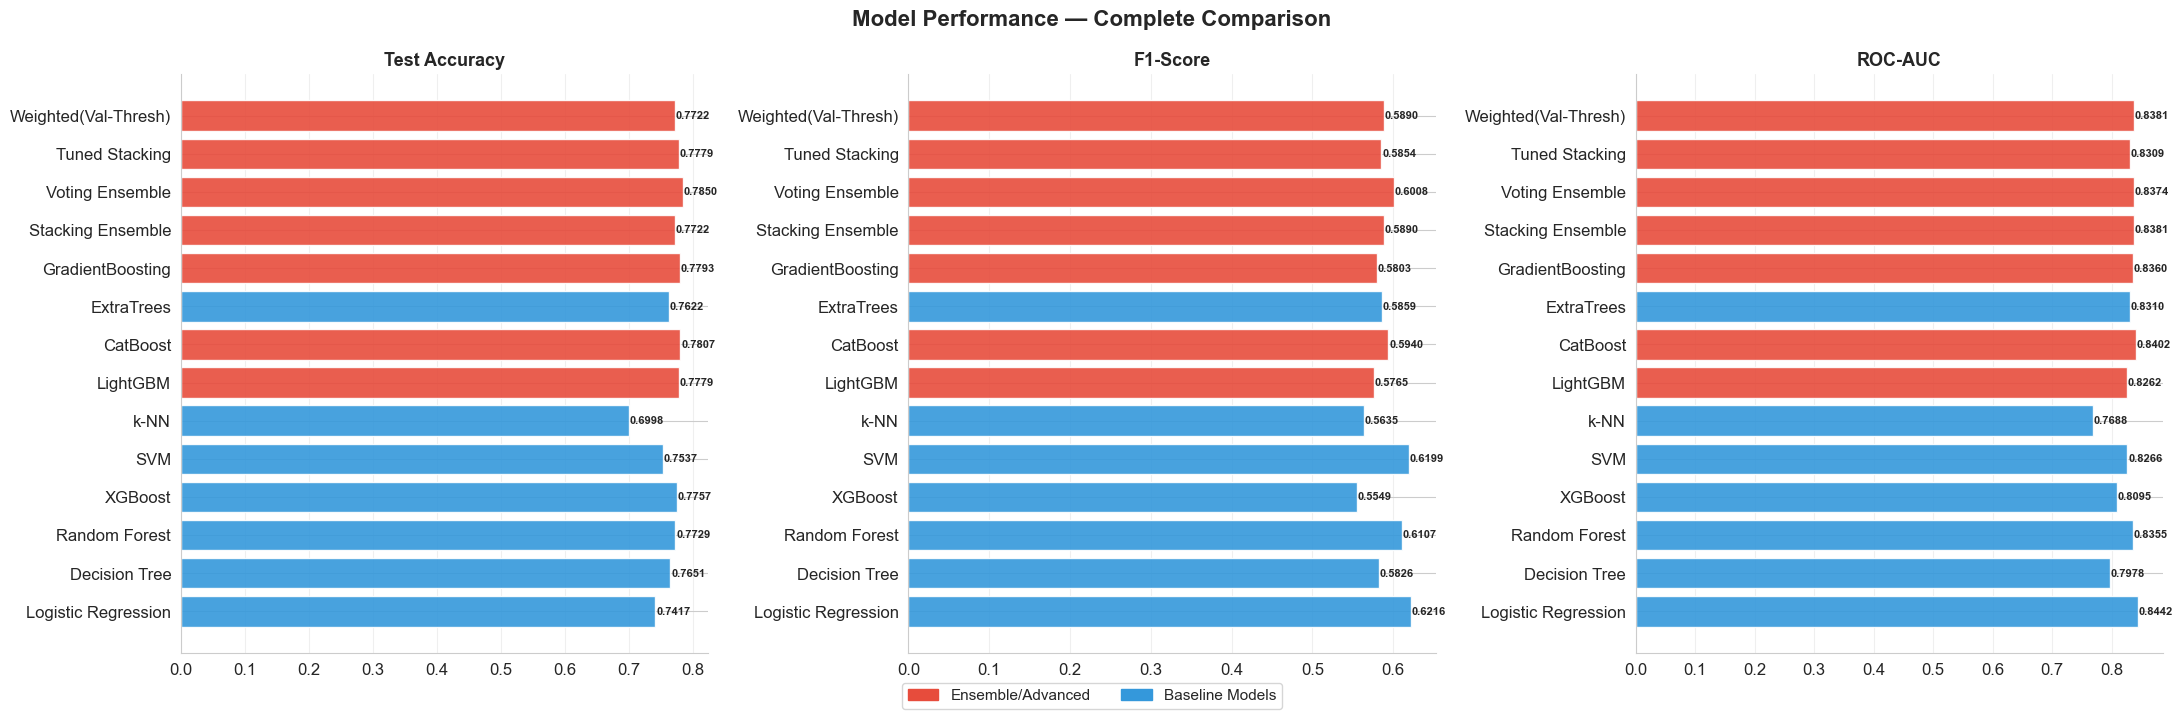

In [ ]:
# Visualization — Final Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Model Performance — Complete Comparison', fontsize=16, fontweight='bold')
ensemble_names = ['Stacking Ensemble','Voting Ensemble','Tuned Stacking',
                  'Weighted(Val-Thresh)','LightGBM','CatBoost','GradientBoosting']
bar_colors = ['#e74c3c' if n in ensemble_names else '#3498db' for n in final.index]
for idx, metric in enumerate(['Test Accuracy','F1-Score','ROC-AUC']):
    vals = final[metric].astype(float).values
    bars = axes[idx].barh(final.index, vals, color=bar_colors, edgecolor='white', alpha=0.9)
    axes[idx].set_title(metric, fontsize=13, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, vals):
        axes[idx].text(val+0.001, bar.get_y()+bar.get_height()/2,
                       f'{val:.4f}', va='center', fontsize=8, fontweight='bold')
    axes[idx].spines['top'].set_visible(False); axes[idx].spines['right'].set_visible(False)
red_p = mpatches.Patch(color='#e74c3c', label='Ensemble/Advanced')
blu_p = mpatches.Patch(color='#3498db', label='Baseline Models')
fig.legend(handles=[red_p,blu_p], loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5,-0.03))
plt.tight_layout(); plt.savefig('16_final_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

---
## Final Summary 🎯

In [ ]:
print("="*70)
print("🏆  CHURNGUARD AI v5.0 — FINAL PROJECT SUMMARY")
print("="*70)
print()
print(f"DATASET  :  Telco Customer Churn  |  7,043 customers  |  {X.shape[1]} features")
print(f"Churn rate: {(y==1).mean()*100:.1f}%  (imbalance handled with SMOTE)")
print()
print("PHASE 1  :  Winsorization → Feature Engineering → Encoding → 80/20 Split")
print("PHASE 2  :  10 supervised models (ALL on SMOTE — fair comparison)")
print("            3 ensemble methods (Stacking, Voting, Weighted)")
print("            3 clustering algorithms (K-Means, Agglomerative, DBSCAN)")
print("            Train accuracy reported on ORIGINAL data — honest metric")
print("PHASE 3  :  Confusion matrices, ROC curves, Feature importance")
print("            Clustering eval: Silhouette + Davies-Bouldin for all 3 methods")
print("PHASE 4  :  GridSearchCV RF (cv=5) | RandomizedSearchCV LGB (cv=5)")
print("            Bayesian Optimization (optional, see commented code)")
print("            Threshold optimized on VALIDATION set — no data leakage")
print()
print(f"🥇 Best Test Accuracy : {final['Test Accuracy'].max():.4f}  —  {final['Test Accuracy'].idxmax()}")
print(f"   Validated Threshold: {best_th:.3f}")
print()
print("="*70)

🏆  CHURNGUARD AI v5.0 — FINAL PROJECT SUMMARY

DATASET  :  Telco Customer Churn  |  7,043 customers  |  54 features
Churn rate: 26.5%  (imbalance handled with SMOTE)

PHASE 1  :  Winsorization → Feature Engineering → Encoding → 80/20 Split
PHASE 2  :  10 supervised models (ALL on SMOTE — fair comparison)
            3 ensemble methods (Stacking, Voting, Weighted)
            3 clustering algorithms (K-Means, Agglomerative, DBSCAN)
            Train accuracy reported on ORIGINAL data — honest metric
PHASE 3  :  Confusion matrices, ROC curves, Feature importance
            Clustering eval: Silhouette + Davies-Bouldin for all 3 methods
PHASE 4  :  GridSearchCV RF (cv=5) | RandomizedSearchCV LGB (cv=5)
            Bayesian Optimization (optional, see commented code)
            Threshold optimized on VALIDATION set — no data leakage

🥇 Best Test Accuracy : 0.7850  —  Voting Ensemble
   Validated Threshold: 0.500



## 4.5 Export Best Model for Deployment (Streamlit App)

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Export Best Model (Voting Ensemble) for Streamlit Deployment
# ═══════════════════════════════════════════════════════════════════
# Voting Ensemble was the BEST model on the test set (see comparison table
# above: Test Accuracy = 0.7850, the highest of all 14 models/ensembles).
# Re-trained here on the FULL training set (X_res_full / scaler_full) so the
# deployed model benefits from all available training data, not just the
# 85%% sub-split used for model comparison.

print("Training final Voting Ensemble on FULL training data for deployment...")
final_voter = VotingClassifier(
    estimators=[
        ('lgb',  LGBMClassifier(n_estimators=300, learning_rate=0.03, max_depth=8,
                                 random_state=42, verbose=-1)),
        ('catb', CatBoostClassifier(iterations=300, learning_rate=0.03, depth=7,
                                     random_seed=42, verbose=0)),
        ('xgb',  XGBClassifier(n_estimators=300, learning_rate=0.03, max_depth=7,
                                random_state=42, verbosity=0)),
    ], voting='soft', weights=[2, 2, 1])

final_voter.fit(X_res_full, y_res_full)

# Evaluate on the untouched test set, scaled with scaler_full (the same
# scaler that will travel with the model into the deployed app)
X_test_full_s = scaler_full.transform(X_test)
final_pred = final_voter.predict(X_test_full_s)
final_prob = final_voter.predict_proba(X_test_full_s)[:, 1]

deploy_metrics = {
    'accuracy': accuracy_score(y_test, final_pred),
    'f1'      : f1_score(y_test, final_pred),
    'roc_auc' : roc_auc_score(y_test, final_prob),
    'report'  : classification_report(y_test, final_pred, target_names=['No Churn','Churn']),
    'cm'      : confusion_matrix(y_test, final_pred),
}

print(f"Deployment model  ->  Test Acc={deploy_metrics['accuracy']:.4f}  "
      f"F1={deploy_metrics['f1']:.4f}  AUC={deploy_metrics['roc_auc']:.4f}")

# Voting Ensemble has no built-in feature_importances_, so average the
# (normalized) importances of its three tree-based base estimators
def _normalize(arr):
    arr = np.array(arr, dtype=float)
    s = arr.sum()
    return arr / s if s > 0 else arr

fi_lgb  = _normalize(final_voter.named_estimators_['lgb'].feature_importances_)
fi_catb = _normalize(final_voter.named_estimators_['catb'].feature_importances_)
fi_xgb  = _normalize(final_voter.named_estimators_['xgb'].feature_importances_)
avg_feature_importance = (fi_lgb + fi_catb + fi_xgb) / 3

artifact = {
    'model'              : final_voter,
    'scaler'             : scaler_full,
    'feature_names'      : list(X.columns),
    'metrics'            : deploy_metrics,
    'feature_importance' : avg_feature_importance,
    'model_name'         : 'Voting Ensemble (LightGBM + CatBoost + XGBoost)',
    'threshold'          : 0.5,
}

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(artifact, f)

print("Saved churn_model.pkl -- model, scaler, feature_names, metrics bundled together")
print("Copy this file into the Streamlit app folder (same directory as app.py)")
